<a href="https://colab.research.google.com/github/Kazusha/Data-Analyse-sur-un-dataset-simuler-sur-des-addictions/blob/main/AddictionDatasetAnalyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creation d'un dataset qui va nous permettre de determiner le moment de rechute d'un individu qui a une addiction

In [1]:
import numpy as np
import pandas as pd
rows =[]
for i in range(1000):
    #Genere les individus
    mood = np.random.randint(1,11)
    stress = np.random.randint(1,11)
    sleeps_hours = np.random.randint(1,11)
    urge_level =np.random.randint(1,11)
    day_of_week =np.random.randint(0,7)
    # calcul du risque_score
    risk_score =(stress * 0.35)+ (urge_level * 0.35)- (mood * 0.3)- (sleeps_hours * 0.2)
    # Transformation en probabilite
    probability = 1 / (1 + np.exp(-risk_score))
    if np.random.rand() < probability:
        relapsed =1
    else:
        relapsed =0

    rows.append([mood,stress,sleeps_hours,urge_level,day_of_week,relapsed])

df = pd.DataFrame(rows, columns=[
    "mood",
    "stress",
    "sleep_hours",
    "urge_level",
    "day_of_week",
    "relapsed"
])

print(df.head())
print(df["relapsed"].mean())
df.to_csv("relapse_dataset.csv", index=False)

   mood  stress  sleep_hours  urge_level  day_of_week  relapsed
0     8      10            2           4            1         1
1     4       1            1           3            0         0
2     1       6            9          10            3         1
3     4       8            1           9            1         1
4    10       4            1           2            5         0
0.668


# Exploration des donnees et visualisation

In [2]:
# Exploration des donnees du dataset
df.describe()

,mood,stress,sleep_hours,urge_level,day_of_week,relapsed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.451000,5.563000,5.521000,5.395000,2.930000,0.668000
std,2.948609,2.900766,2.917888,2.861672,2.023659,0.471167
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,3.000000,3.000000,3.000000,3.000000,1.000000,0.000000
50%,5.000000,5.500000,6.000000,5.000000,3.000000,1.000000
75%,8.000000,8.000000,8.000000,8.000000,5.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,6.000000,1.000000


array([[<Axes: title={'center': 'mood'}>,
        <Axes: title={'center': 'stress'}>],
       [<Axes: title={'center': 'sleep_hours'}>,
        <Axes: title={'center': 'urge_level'}>],
       [<Axes: title={'center': 'day_of_week'}>,
        <Axes: title={'center': 'relapsed'}>]], dtype=object)

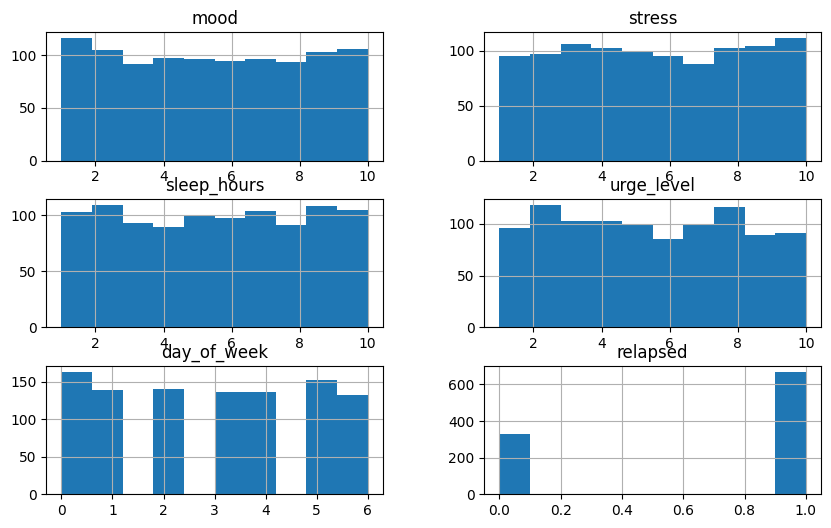

In [3]:
df.hist(figsize=(10,6))

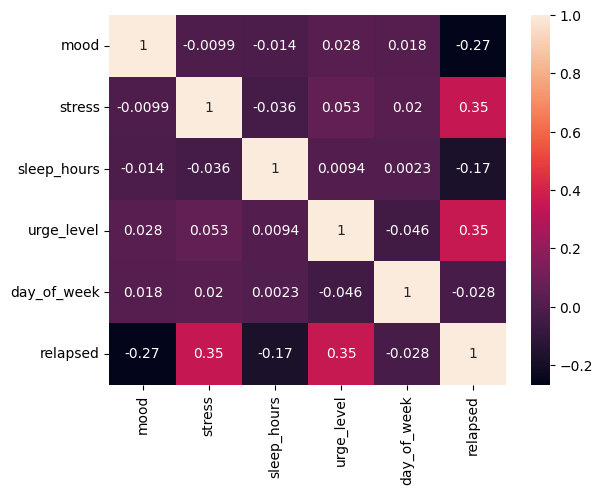

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr()
sns.heatmap(corr, annot= True)
plt.show()

# Split X/Y et entrainement

In [5]:
# Features (X) et Target (Y)
X= df[["mood" ,"stress" , "sleep_hours" , "urge_level" , "day_of_week"]]
Y = df["relapsed"]
print(X.head())
print(Y.head())

   mood  stress  sleep_hours  urge_level  day_of_week
0     8      10            2           4            1
1     4       1            1           3            0
2     1       6            9          10            3
3     4       8            1           9            1
4    10       4            1           2            5
0    1
1    0
2    1
3    1
4    0
Name: relapsed, dtype: int64


In [6]:
# Split train et test
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size =0.2 , random_state =42)
print("X_train:" , X_train.shape)
print("X_test:" , X_test.shape)
print("Y_train:" , Y_train.shape)
print("Y_test:" , Y_test.shape)

X_train: (800, 5)
X_test: (200, 5)
Y_train: (800,)
Y_test: (200,)


In [7]:
#Standardisation du modele
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Resultat pour X_train_scaled:  ",X_train_scaled[0])
print("Resultat pour X_test_scaled:  ",X_test_scaled[0])

Resultat pour X_train_scaled:   [-1.15020371  1.52012319 -1.52166331  1.24429255  1.50142528]
Resultat pour X_test_scaled:   [1.54822142 1.52012319 1.54123181 1.59028978 0.03721534]


In [8]:
# Regression logistique
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

model = LogisticRegression()
model.fit(X_train_scaled , Y_train)
y_pred = model.predict(X_test_scaled)


In [9]:
# Accuracy globale
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score

print("Accuracy :", accuracy_score(Y_test, y_pred))
print("Precision :", precision_score(Y_test, y_pred))
print("Recall :", recall_score(Y_test, y_pred))
print("F1-score :", f1_score(Y_test, y_pred))

Accuracy : 0.76
Precision : 0.8102189781021898
Recall : 0.8345864661654135
F1-score : 0.8222222222222222


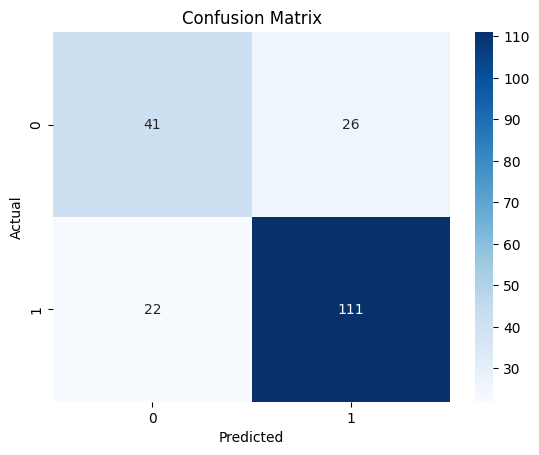

In [10]:
# Matrice de confusion
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

mood : -0.912
stress : 1.035
sleep_hours : -0.590
urge_level : 1.041
day_of_week : -0.074


/tmp/ipython-input-587/3896740154.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=coefs, palette="coolwarm")


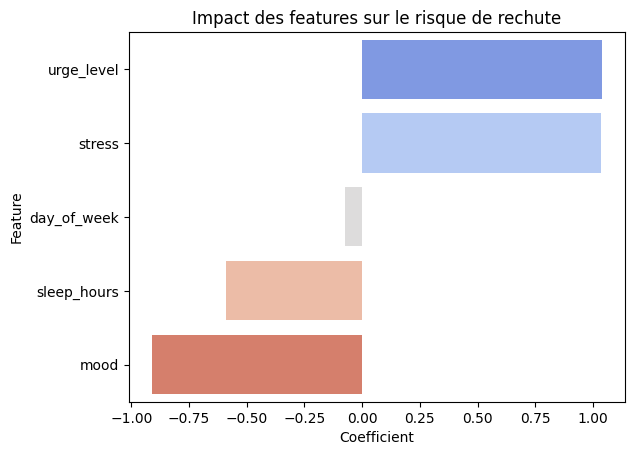

In [11]:
import pandas as pd
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature} : {coef:.3f}")

coefs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

sns.barplot(x="Coefficient", y="Feature", data=coefs, palette="coolwarm")
plt.title("Impact des features sur le risque de rechute")
plt.show()

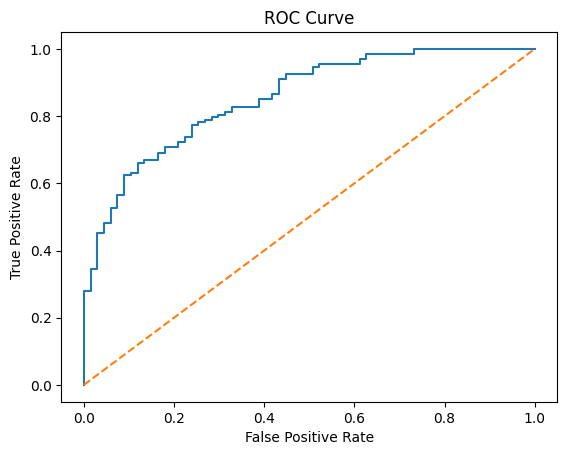

AUC : 0.85444955672764


In [12]:
# ROC Curve et AUC
from sklearn.metrics import roc_curve , roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test_scaled)[:,1]
fpr , tpr , thresolds =  roc_curve(Y_test , y_proba)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC :", roc_auc_score(Y_test, y_proba))


In [13]:
#  Utilisation du Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train , Y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [14]:
print("Accuracy :", accuracy_score(Y_test, y_pred_rf))
print("Precision :", precision_score(Y_test, y_pred_rf))
print("Recall :", recall_score(Y_test, y_pred_rf))
print("F1-score :", f1_score(Y_test, y_pred_rf))


Accuracy : 0.75
Precision : 0.8074074074074075
Recall : 0.8195488721804511
F1-score : 0.8134328358208955


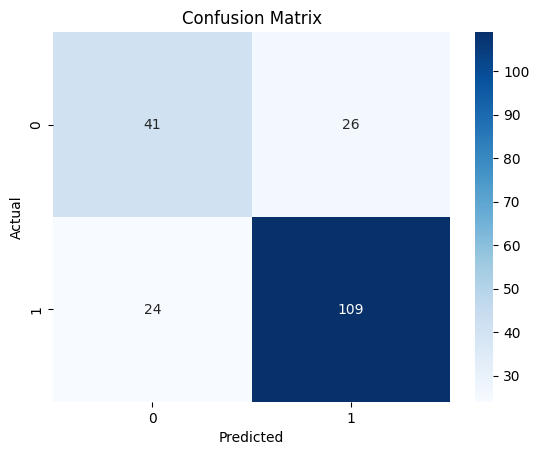

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

stress         0.245670
urge_level     0.232374
mood           0.215043
sleep_hours    0.174476
day_of_week    0.132436
dtype: float64


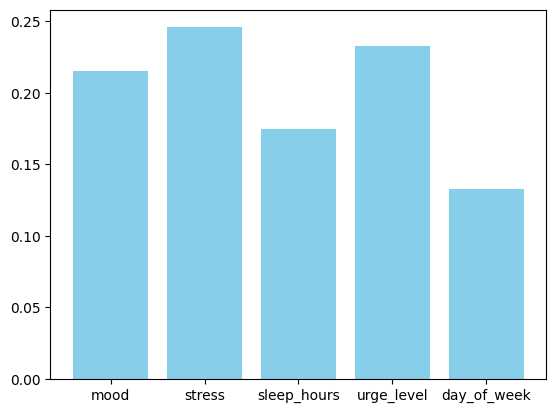

In [18]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))
plt.bar(X.columns , rf.feature_importances_ , color='skyblue')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


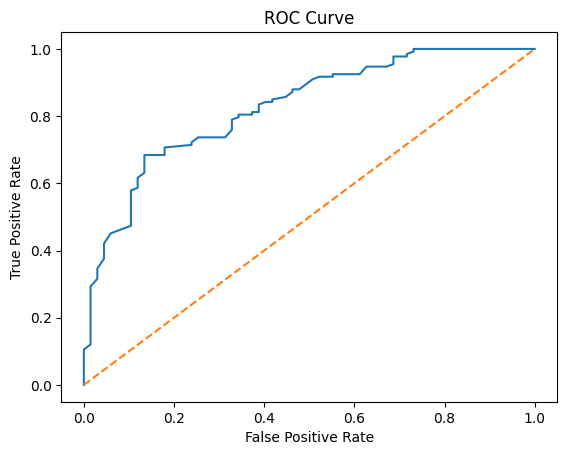

AUC : 0.8266187857703962


In [19]:
# ROC Curve et AUC
from sklearn.metrics import roc_curve , roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:,1]
fpr , tpr , thresolds =  roc_curve(Y_test , y_prob_rf)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC :", roc_auc_score(Y_test, y_prob_rf))


In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

# Création pipeline
pipeline = make_pipeline(StandardScaler(), LogisticRegression())

# Entraînement
pipeline.fit(X_train, Y_train)

# Sauvegarde
joblib.dump(pipeline, "relapse_model.pkl")

['relapse_model.pkl']

In [21]:
import os
print(os.getcwd())

/content
